<a href="https://colab.research.google.com/github/Deepu9981/FitPulse-Health-Anomaly-Detection-from-Fitness-Devices/blob/main/modeling_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import files
df = files.upload()

Saving FitPulse_final_dataset.csv to FitPulse_final_dataset.csv


In [7]:
data=pd.read_csv('/content/drive/MyDrive/FitPulse Health Anomaly Detection from Fitness Devices/FitPulse_final_dataset.csv')

In [8]:
df

{'FitPulse_final_dataset.csv': b'Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate\nP0001,74.49965332674955,26.0,,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72\nP0002,90.83311557124816,6.0,,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86\nP0003,61.27077417459431,40.0,,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63\nP0005,59.80786890023052,29.0,,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91\nP0006,92.70217878935284,34.0,,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93\nP0007,73.48979562574198,22.0,,2025-01-07 03:55:00,68,171,M,43,2614,7.2,9210,66\nP0008,78.59158440010617,43.0,,2025-01-05 14:50:00,72,162,M,69,2898,8.3,6594,60\nP0009,72.58508360973464,15.0,,2025-01-03 21:00:00,60,158,F,31,1770,8.2,9479,92\nP0010,58.85567044894326,12.0,,2025-01-12 03:00:00,60,182,F,48,2083,7.7,9228,94\nP0011,82.0026941965946,16.0,,2025-01-01 01:10:00,73,163,M,17,2697,9.6,15533,95\nP0012,69.5332114593

In [17]:
df_prophet = data.rename(columns={
    "time_stamp": "ds",
    "resting_heart_rate": "y"
})

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"]).dt.tz_localize(None)

In [18]:
from prophet import Prophet

model = Prophet()
model.fit(df_prophet)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [24]:
future = model.make_future_dataframe(periods=10, freq="min")
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

                      ds       yhat  yhat_lower  yhat_upper
7887 2025-12-01 00:16:00  78.444165   63.569925   92.861809
7888 2025-12-01 00:17:00  78.449247   62.765961   92.668229
7889 2025-12-01 00:18:00  78.454344   63.410655   93.679983
7890 2025-12-01 00:19:00  78.459457   63.770877   92.920060
7891 2025-12-01 00:20:00  78.464583   63.518552   94.255645


In [21]:
future = model.make_future_dataframe(periods=10, freq="T")

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(


In [22]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-01 00:00:00,80.337347,65.438085,94.555256,80.337347,80.337347,0.136479,0.136479,0.136479,-0.012220,-0.012220,-0.012220,0.148699,0.148699,0.148699,0.0,0.0,0.0,80.473826
1,2025-01-01 00:05:00,80.337321,64.432835,95.684401,80.337321,80.337321,0.163726,0.163726,0.163726,0.016685,0.016685,0.016685,0.147041,0.147041,0.147041,0.0,0.0,0.0,80.501047
2,2025-01-01 00:10:00,80.337296,65.052173,95.594554,80.337296,80.337296,0.191656,0.191656,0.191656,0.046297,0.046297,0.046297,0.145359,0.145359,0.145359,0.0,0.0,0.0,80.528951
3,2025-01-01 00:15:00,80.337270,66.140723,96.166735,80.337270,80.337270,0.220147,0.220147,0.220147,0.076494,0.076494,0.076494,0.143653,0.143653,0.143653,0.0,0.0,0.0,80.557417
4,2025-01-01 00:20:00,80.337245,66.416577,94.813935,80.337245,80.337245,0.249075,0.249075,0.249075,0.107151,0.107151,0.107151,0.141924,0.141924,0.141924,0.0,0.0,0.0,80.586320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7887,2025-12-01 00:16:00,77.873188,62.812344,92.237590,77.873188,77.873188,0.570978,0.570978,0.570978,0.082593,0.082593,0.082593,0.488385,0.488385,0.488385,0.0,0.0,0.0,78.444165
7888,2025-12-01 00:17:00,77.873182,63.871710,93.988100,77.873182,77.873182,0.576065,0.576065,0.576065,0.088709,0.088709,0.088709,0.487356,0.487356,0.487356,0.0,0.0,0.0,78.449247
7889,2025-12-01 00:18:00,77.873177,63.636305,92.847626,77.873177,77.873177,0.581167,0.581167,0.581167,0.094841,0.094841,0.094841,0.486326,0.486326,0.486326,0.0,0.0,0.0,78.454344
7890,2025-12-01 00:19:00,77.873172,63.404829,93.442448,77.873172,77.873172,0.586285,0.586285,0.586285,0.100989,0.100989,0.100989,0.485296,0.485296,0.485296,0.0,0.0,0.0,78.459457


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


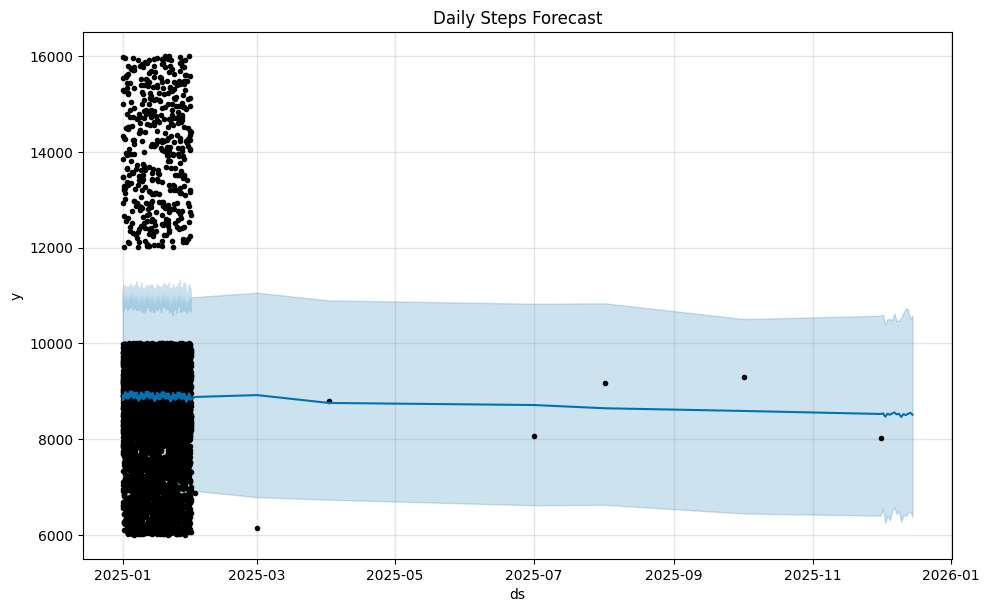

In [25]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data
df_steps = data[['time_stamp', 'daily_steps']].rename(
    columns={'time_stamp': 'ds', 'daily_steps': 'y'}
)
df_steps['ds'] = pd.to_datetime(df_steps['ds']).dt.tz_localize(None)

# Train model
model_steps = Prophet()
model_steps.fit(df_steps)

# Predict
future_steps = model_steps.make_future_dataframe(periods=14, freq='D')
forecast_steps = model_steps.predict(future_steps)

# Plot
model_steps.plot(forecast_steps)
plt.title('Daily Steps Forecast')
plt.show()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


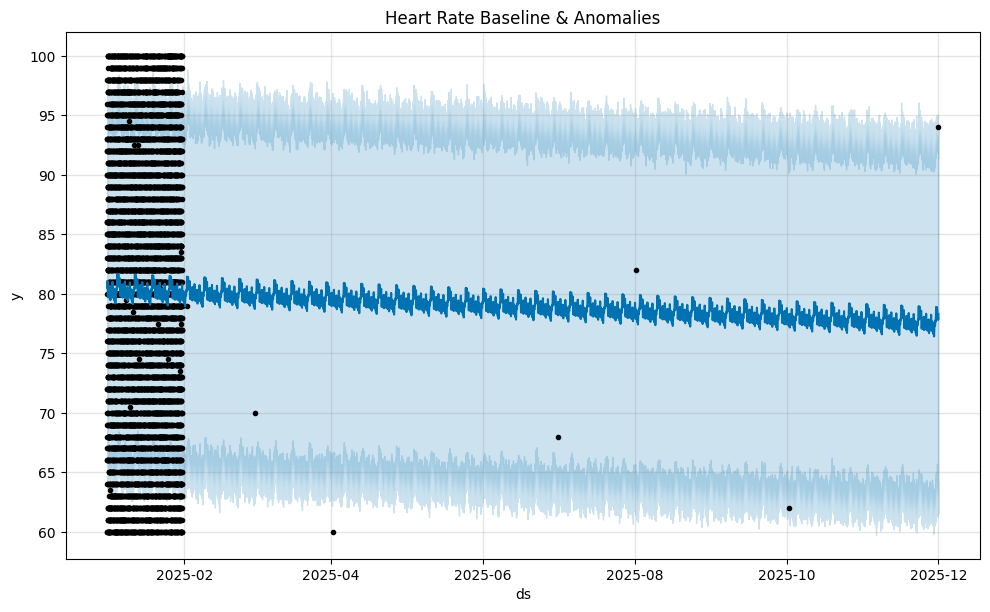

In [28]:
# Resample heart rate
df_hr = (
    data[["time_stamp", "resting_heart_rate"]]
    .copy()
)
df_hr["time_stamp"] = pd.to_datetime(df_hr["time_stamp"]) # Convert 'time_stamp' column to datetime objects
df_hr = df_hr.set_index("time_stamp").resample("5min").mean().reset_index()

# Prophet format
df_hr = df_hr.rename(columns={"time_stamp": "ds", "resting_heart_rate": "y"})
df_hr["ds"] = pd.to_datetime(df_hr["ds"])

# Train
model_hr = Prophet(daily_seasonality=True)
model_hr.fit(df_hr)

# Predict
future_hr = model_hr.make_future_dataframe(periods=10, freq="5min")
forecast_hr = model_hr.predict(future_hr)

# Plot
model_hr.plot(forecast_hr)
plt.title("Heart Rate Baseline & Anomalies")
plt.show()

In [46]:
import pandas as pd

# Merge actual heart rate data with the forecast
anomaly_detection_df = pd.merge(df_hr, forecast_hr[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='inner')

# Identify anomalies: actual value outside the forecasted upper or lower bound
anomalies = anomaly_detection_df[
    (anomaly_detection_df['y'] < anomaly_detection_df['yhat_lower']) |
    (anomaly_detection_df['y'] > anomaly_detection_df['yhat_upper'])
]

print("Potential Heart Rate Anomalies (actual value outside forecast range):")
display(anomalies.head())

Potential Heart Rate Anomalies (actual value outside forecast range):


,ds,y,yhat,yhat_lower,yhat_upper
1,2025-01-01 00:05:00,66.0,80.522988,66.004681,95.147959
2,2025-01-01 00:10:00,98.0,80.550586,65.200707,95.263376
12,2025-01-01 01:00:00,96.0,80.839585,65.597793,95.901472
19,2025-01-01 01:35:00,60.0,81.007051,66.295274,96.432047
26,2025-01-01 02:10:00,64.0,81.096000,65.387867,95.719213


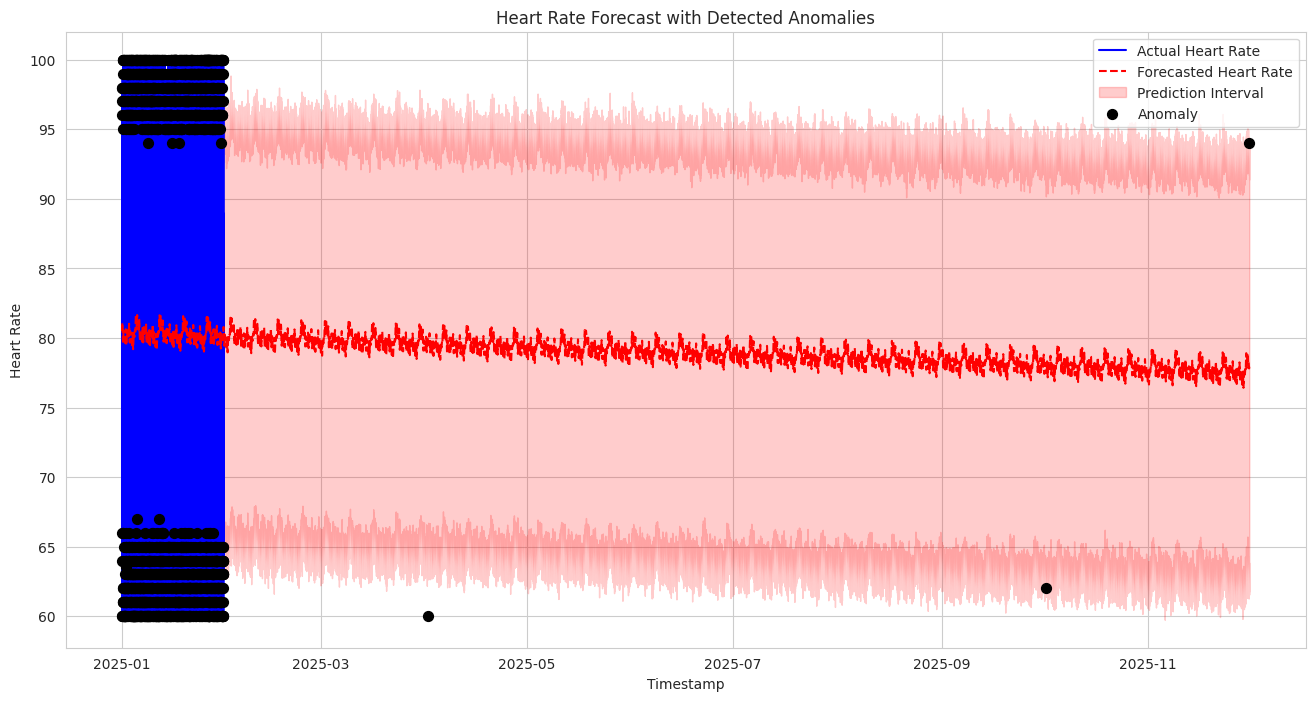

In [47]:
import matplotlib.pyplot as plt

# Plot the forecast with anomalies highlighted
plt.figure(figsize=(16, 8))
plt.plot(anomaly_detection_df['ds'], anomaly_detection_df['y'], label='Actual Heart Rate', color='blue')
plt.plot(anomaly_detection_df['ds'], anomaly_detection_df['yhat'], label='Forecasted Heart Rate', color='red', linestyle='--')
plt.fill_between(anomaly_detection_df['ds'], anomaly_detection_df['yhat_lower'], anomaly_detection_df['yhat_upper'], color='red', alpha=0.2, label='Prediction Interval')

# Highlight anomalies
plt.scatter(anomalies['ds'], anomalies['y'], color='black', marker='o', s=50, zorder=5, label='Anomaly')

plt.title('Heart Rate Forecast with Detected Anomalies')
plt.xlabel('Timestamp')
plt.ylabel('Heart Rate')
plt.legend()
plt.show()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


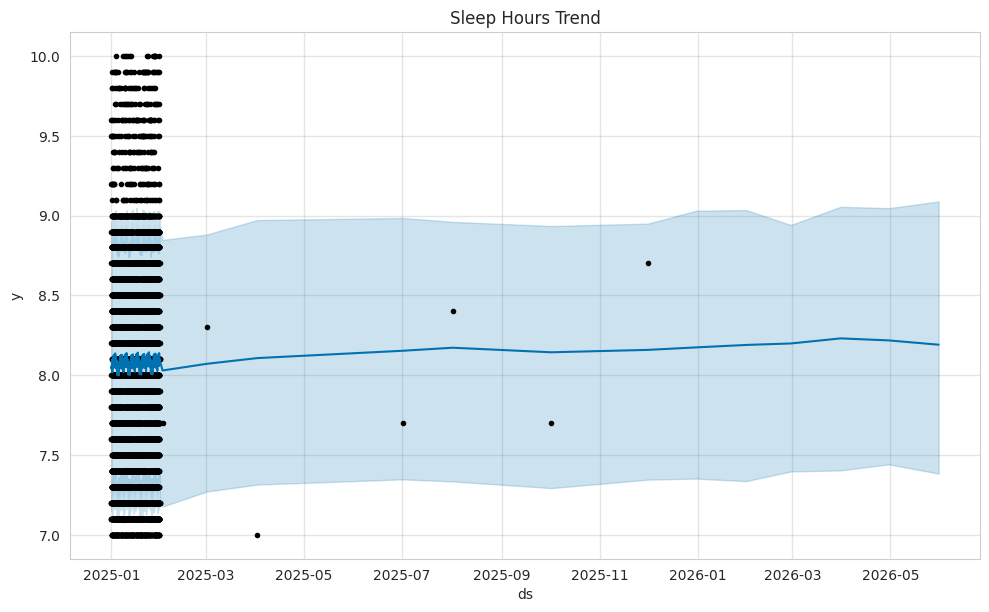

In [51]:
df_sleep = data[["time_stamp", "daily_sleep_hours"]].rename(
    columns={"time_stamp": "ds", "daily_sleep_hours": "y"}
)
df_sleep["ds"] = pd.to_datetime(df_sleep["ds"]).dt.tz_localize(None)

model_sleep = Prophet(weekly_seasonality=True)
model_sleep.fit(df_sleep)

future_sleep = model_sleep.make_future_dataframe(periods=6, freq="ME") # Changed 'M' to 'ME'
forecast_sleep = model_sleep.predict(future_sleep)

model_sleep.plot(forecast_sleep)
plt.title("Sleep Hours Trend")
plt.show()

In [52]:
data.columns

Index(['Patient_ID', 'heart_rate', 'step_count', 'sleep_tracking',
       'time_stamp', 'Weight', 'Height', 'gender', 'age', 'daily_calories',
       'daily_sleep_hours', 'daily_steps', 'resting_heart_rate'],
      dtype='object')

In [54]:
import pandas as pd

# Assuming 'data' is your DataFrame
data["Time"] = pd.to_datetime(data["time_stamp"])

# Create day window
data["day"] = data["Time"].dt.date

# Display the head of the modified DataFrame to show the new columns
display(data[['time_stamp', 'Time', 'day']].head())

,time_stamp,Time,day
0,2025-01-14 16:50:00,2025-01-14 16:50:00,2025-01-14
1,2025-01-21 08:55:00,2025-01-21 08:55:00,2025-01-21
2,2025-01-17 07:10:00,2025-01-17 07:10:00,2025-01-17
3,2025-01-18 18:25:00,2025-01-18 18:25:00,2025-01-18
4,2025-01-13 07:20:00,2025-01-13 07:20:00,2025-01-13


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('time_stamp').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('day').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Time']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Time'}, axis=1)
              .sort_values('Time', ascending=True))
  xs = counted['Time']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('Time', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('time_stamp')):
  _plot_series(series, series_name, i)
  fig.legend(title='time_stamp', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Time')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Time']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Time'}, axis=1)
              .sort_values('Time', ascending=True))
  xs = counted['Time']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('Time', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('day')):
  _plot_series(series, series_name, i)
  fig.legend(title='day', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Time')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['time_stamp']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'time_stamp'}, axis=1)
              .sort_values('time_stamp', ascending=True))
  xs = counted['time_stamp']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('time_stamp', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('time_stamp')):
  _plot_series(series, series_name, i)
  fig.legend(title='time_stamp', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('time_stamp')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['time_stamp']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'time_stamp'}, axis=1)
              .sort_values('time_stamp', ascending=True))
  xs = counted['time_stamp']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_5.sort_values('time_stamp', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('day')):
  _plot_series(series, series_name, i)
  fig.legend(title='day', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('time_stamp')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['day'].value_counts()
    for x_label, grp in _df_6.groupby('time_stamp')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('time_stamp')
_ = plt.ylabel('day')

In [59]:
from tsfresh.utilities.dataframe_functions import roll_time_series

value_columns = ["resting_heart_rate", "daily_steps", "daily_sleep_hours"]

tsfresh_input = data.melt(
    id_vars=["Patient_ID", "Time", "day"],
    value_vars=value_columns,
    var_name="kind",
    value_name="value"
)

tsfresh_input = tsfresh_input.rename(columns={
    "day": "id",
    "Time": "time"
})

tsfresh_input = tsfresh_input[["id", "time", "kind", "value"]]

In [62]:
# Safety cleaning
tsfresh_input.replace([np.inf, -np.inf], np.nan, inplace=True)
tsfresh_input.dropna(inplace=True)

#If infinity / NaN exists → TSFresh WILL FAIL.

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from tsfresh import extract_features

# Extract features from tsfresh_input
tsfresh_features = extract_features(
    tsfresh_input,
    column_id="id",
    column_sort="time",
    column_kind="kind",
    column_value="value",
    n_jobs=0 # Use n_jobs=0 to avoid multiprocessing issues in Colab
)

# Remove columns with NaN or Inf values after feature extraction, if any
tsfresh_features.replace([np.inf, -np.inf], np.nan, inplace=True)
tsfresh_features.dropna(axis=1, inplace=True)


X = tsfresh_features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init to suppress future warning
tsfresh_features["cluster"] = kmeans.fit_predict(X_scaled)

Feature Extraction: 100%|██████████| 114/114 [00:18<00:00,  6.00it/s]


In [65]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_scores[k] = score
    print(f"K={k}, Silhouette Score={score:.3f}")


K=2, Silhouette Score=0.672
K=3, Silhouette Score=0.162
K=4, Silhouette Score=0.155
K=5, Silhouette Score=0.161
K=6, Silhouette Score=0.158


In [66]:
print(tsfresh_features.groupby("cluster").mean())

         daily_sleep_hours__variance_larger_than_standard_deviation  \
cluster                                                               
0                                                      0.0            
1                                                      0.0            
2                                                      0.0            

         daily_sleep_hours__has_duplicate_max  \
cluster                                         
0                                    0.000000   
1                                    0.433333   
2                                    0.000000   

         daily_sleep_hours__has_duplicate_min  \
cluster                                         
0                                         0.0   
1                                         1.0   
2                                         0.0   

         daily_sleep_hours__has_duplicate  daily_sleep_hours__sum_values  \
cluster                                                                    


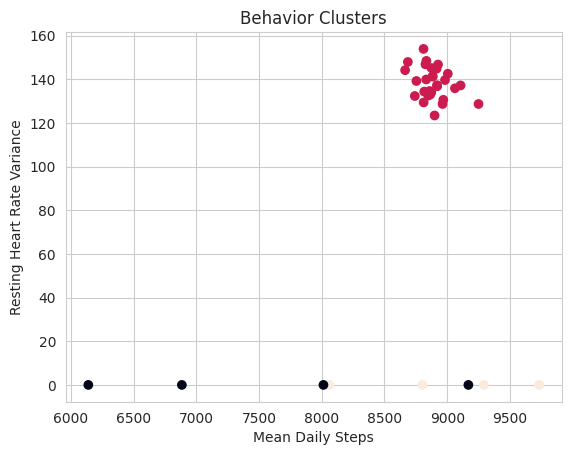

In [68]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    tsfresh_features["daily_steps__mean"],
    tsfresh_features["resting_heart_rate__variance"],
    c=tsfresh_features["cluster"]
)
plt.xlabel("Mean Daily Steps")
plt.ylabel("Resting Heart Rate Variance")
plt.title("Behavior Clusters")
plt.show()